In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from scipy.signal import butter, lfilter
import scipy.stats as sci

In [2]:
def valMap(value, istart, istop, ostart, ostop):
        return ostart + (ostop - ostart) * ((value - istart) / (istop - istart))

In [3]:
FOLDER = 'data'
files = os.listdir(FOLDER)

trajectories_0 = list(filter(lambda x: 'trajectory' in x and 'v0' in x, files))
trajectories_1 = list(filter(lambda x: 'trajectory' in x and 'v1' in x, files))
trajectories_2 = list(filter(lambda x: 'trajectory' in x and 'v2' in x, files))

allos_0 = list(filter(lambda x: 'allostatic' in x and 'v0' in x, files))
allos_1 = list(filter(lambda x: 'allostatic' in x and 'v1' in x, files))
allos_2 = list(filter(lambda x: 'allostatic' in x and 'v2' in x, files))

In [4]:
df_trajectory_0 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 500000) for x in trajectories_0])
df_trajectory_1 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 500000) for x in trajectories_1])
df_trajectory_2 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 500000) for x in trajectories_2])

In [5]:
df_allo_0 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 145000) for x in allos_0])
df_allo_1 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 145000) for x in allos_1])
df_allo_2 = pd.concat([pd.read_csv(os.path.join(FOLDER, x), nrows = 145000) for x in allos_2])

In [30]:
df_trajectory = df_trajectory_1
df_allo = df_allo_1

### Trajectory

In [31]:
XPose = df_trajectory['XPosition'].to_list()
YPose = df_trajectory['YPosition'].to_list()

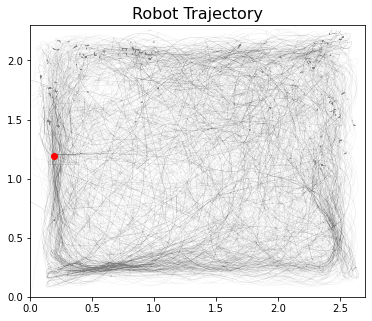

In [53]:
plt.figure(figsize=(6, 5))
plt.plot(XPose, YPose, linewidth=0.05, color='grey')
plt.title('Robot Trajectory', fontsize=16)
plt.plot(0.19,1.19,'ro')
plt.xlim(0.0, 2.7)
plt.ylim(0.0, 2.3)
plt.show()

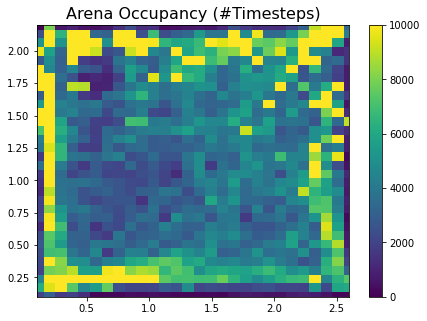

In [54]:
plt.figure(figsize=(7, 5))
plt.hist2d(XPose, YPose, bins=35, density=False, vmax=10000) 
plt.colorbar()
plt.title('Arena Occupancy (#Timesteps)', fontsize=16)
plt.xlim(0.1, 2.6)
plt.ylim(0.1, 2.2)
plt.show()

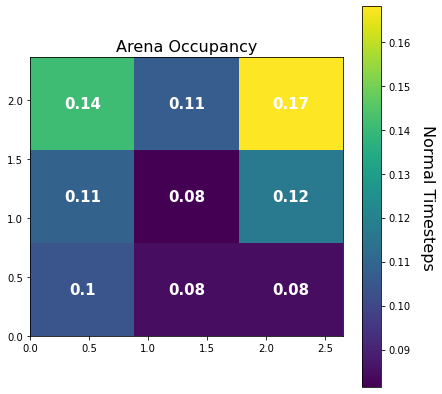

In [55]:
xy_array = np.column_stack((XPose, YPose))
x_array = xy_array[:,0]
y_array = xy_array[:,1]

bins = 3
xedges= []
yedges= []
for i in range(bins):
    xedges.append((max(XPose)/bins)*i)
    yedges.append((max(YPose)/bins)*i)
xedges.append((max(XPose)))
yedges.append((max(YPose)))

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect("equal")
hist, xbins, ybins, im = ax.hist2d(x_array, y_array, bins=(xedges, yedges))
H = hist.T
H_normalized = H/float(xy_array.shape[0])

for i in range(len(ybins)-1):
    for j in range(len(xbins)-1):
        ax.text(xbins[j]+xedges[1]/2, ybins[i]+yedges[1]/2, round(H_normalized[i,j],2), fontsize=15, ha="center", va="center", color="w", fontweight="bold")      
        
ax.set_title('Arena Occupancy', fontsize=16)
hist = ax.imshow(H_normalized, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
cbar = fig.colorbar(hist)
cbar.set_label('Normal Timesteps', rotation=270, fontsize=16, labelpad=+25)
plt.show()

### Homeostasis

#### Actual value aV

In [35]:
print("Energy:")
print("Interoceptive:", round(df_allo_0['aVEnergy'].mean(),3), round(df_allo_0['aVEnergy'].std(),3), round(df_allo_0['aVEnergy'].min(),3))
print("Exteroceptive:", round(df_allo_1['aVEnergy'].mean(),3), round(df_allo_1['aVEnergy'].std(),3), round(df_allo_1['aVEnergy'].min(),3))
print("Constant k:", round(df_allo_2['aVEnergy'].mean(),3), round(df_allo_2['aVEnergy'].std(),3), round(df_allo_2['aVEnergy'].min(),3))

Energy:
Interoceptive: 0.849 0.16 0.1
Exteroceptive: 0.833 0.146 0.1
Constant k: 0.756 0.19 0.1


In [36]:
print("Water:")
print("Interoceptive:", round(df_allo_0['aVWater'].mean(),3), round(df_allo_0['aVWater'].std(),3), round(df_allo_0['aVWater'].min(),3))
print("Exteroceptive:", round(df_allo_1['aVWater'].mean(),3), round(df_allo_1['aVWater'].std(),3), round(df_allo_1['aVWater'].min(),3))
print("Constant k:", round(df_allo_2['aVWater'].mean(),3), round(df_allo_2['aVWater'].std(),3), round(df_allo_2['aVWater'].min(),3))

Water:
Interoceptive: 0.812 0.186 0.1
Exteroceptive: 0.744 0.222 0.1
Constant k: 0.664 0.25 0.1


In [37]:
print("Temperature:")
print("Interoceptive:", round(df_allo_0['aVTemp'].mean(),3), round(df_allo_0['aVTemp'].std(),3), round(df_allo_0['aVTemp'].min(),3))
print("Exteroceptive:", round(df_allo_1['aVTemp'].mean(),3), round(df_allo_1['aVTemp'].std(),3), round(df_allo_1['aVTemp'].min(),3))
print("Constant k:", round(df_allo_2['aVTemp'].mean(),3), round(df_allo_2['aVTemp'].std(),3), round(df_allo_2['aVTemp'].min(),3))

Temperature:
Interoceptive: 0.624 0.35 0.1
Exteroceptive: 0.597 0.364 0.1
Constant k: 0.556 0.359 0.1


In [38]:
df_energy_aV = df_allo['aVEnergy']
print(round(df_energy_aV.mean(),3), round(df_energy_aV.std(),3), round(df_energy_aV.min(),3))

stat_normal, p_normal = sci.normaltest(df_energy_aV)
print("Normality test p value = " + str(p_normal))

0.833 0.146 0.1
Normality test p value = 0.0


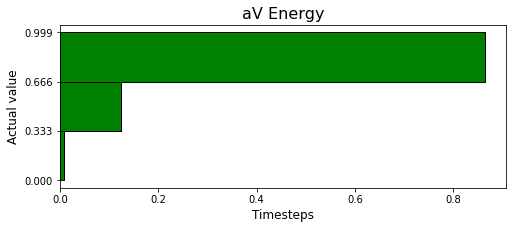

In [56]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_energy_aV)/float(len(df_energy_aV))
plt.hist(df_energy_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "green", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Energy', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [40]:
df_water_aV = df_allo['aVWater']
print(round(df_water_aV.mean(),3), round(df_water_aV.std(),3), round(df_water_aV.min(),3))
stat_normal, p_normal = sci.normaltest(df_water_aV) 
print("Normality test p value = " + str(p_normal))

0.744 0.222 0.1
Normality test p value = 0.0


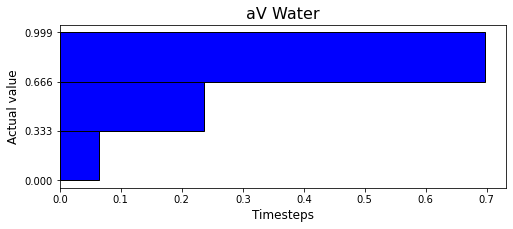

In [57]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_water_aV)/float(len(df_water_aV))
plt.hist(df_water_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "blue", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Water', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [42]:
df_temp_aV = df_allo['aVTemp']
print(round(df_temp_aV.mean(), 3), round(df_temp_aV.std(), 3), round(valMap(df_temp_aV.mean(), 0, 1, 50, 20), 1))
stat_normal, p_normal = sci.normaltest(df_temp_aV) 
print("Normality test p value = " + str(p_normal))

0.597 0.364 32.1
Normality test p value = 0.0


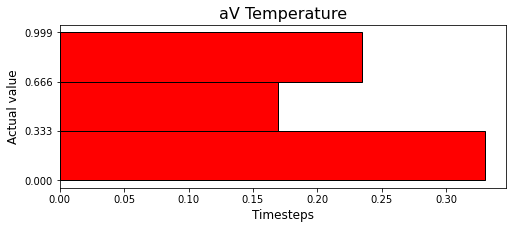

In [58]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_temp_aV)/float(len(df_temp_aV))
plt.hist(df_temp_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "red", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Temperature', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

#### Intensity ∣aV - dV∣

In [44]:
print("Hunger:")
print("Interoceptive:", round(df_allo_0['UHunger'].mean(),3), round(df_allo_0['UHunger'].std(),3))
print("Exteroceptive:", round(df_allo_1['UHunger'].mean(),3), round(df_allo_1['UHunger'].std(),3))
print("Constant k:", round(df_allo_2['UHunger'].mean(),3), round(df_allo_2['UHunger'].std(),3))

Hunger:
Interoceptive: 0.055 0.129
Exteroceptive: 0.064 0.112
Constant k: 0.126 0.161


In [45]:
print("Thirst:")
print("Interoceptive:", round(df_allo_0['UThirst'].mean(),3), round(df_allo_0['UThirst'].std(),3))
print("Exteroceptive:", round(df_allo_1['UThirst'].mean(),3), round(df_allo_1['UThirst'].std(),3))
print("Constant k:", round(df_allo_2['UThirst'].mean(),3), round(df_allo_2['UThirst'].std(),3))

Thirst:
Interoceptive: 0.144 0.181
Exteroceptive: 0.211 0.218
Constant k: 0.289 0.247


In [46]:
print("Temperature:")
print("Interoceptive:", round(df_allo_0['UTemp'].mean(),3), round(df_allo_0['UTemp'].std(),3))
print("Exteroceptive:", round(df_allo_1['UTemp'].mean(),3), round(df_allo_1['UTemp'].std(),3))
print("Constant k:", round(df_allo_2['UTemp'].mean(),3), round(df_allo_2['UTemp'].std(),3))

Temperature:
Interoceptive: 0.303 0.313
Exteroceptive: 0.335 0.33
Constant k: 0.364 0.327


{'whiskers': [<matplotlib.lines.Line2D at 0x17e664eb0>,
 'caps': [<matplotlib.lines.Line2D at 0x17e671610>,
 'boxes': [<matplotlib.lines.Line2D at 0x17e664b20>,
 'medians': [<matplotlib.lines.Line2D at 0x17e671d30>,
 'fliers': [<matplotlib.lines.Line2D at 0x17e67d100>,
 'means': []}

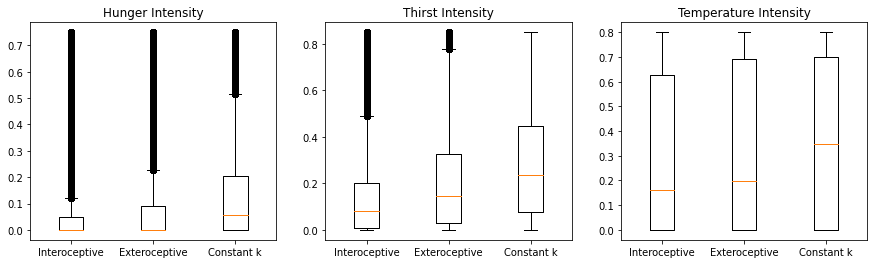

In [47]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].set_title('Hunger Intensity')
axs[0].boxplot([df_allo_0['UHunger'], df_allo_1['UHunger'], df_allo_2['UHunger']], 
            labels=['Interoceptive','Exteroceptive','Constant k'])

axs[1].set_title('Thirst Intensity')
axs[1].boxplot([df_allo_0['UThirst'], df_allo_1['UThirst'], df_allo_2['UThirst']], 
            labels=['Interoceptive','Exteroceptive','Constant k'])

axs[2].set_title('Temperature Intensity')
axs[2].boxplot([df_allo_0['UTemp'], df_allo_1['UTemp'], df_allo_2['UTemp']], 
            labels=['Interoceptive','Exteroceptive','Constant k'])

{'whiskers': [<matplotlib.lines.Line2D at 0x17e0678e0>,
 'caps': [<matplotlib.lines.Line2D at 0x17e054130>,
 'boxes': [<matplotlib.lines.Line2D at 0x17e067ca0>,
 'medians': [<matplotlib.lines.Line2D at 0x11d8657c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x11d865b20>,
 'means': []}

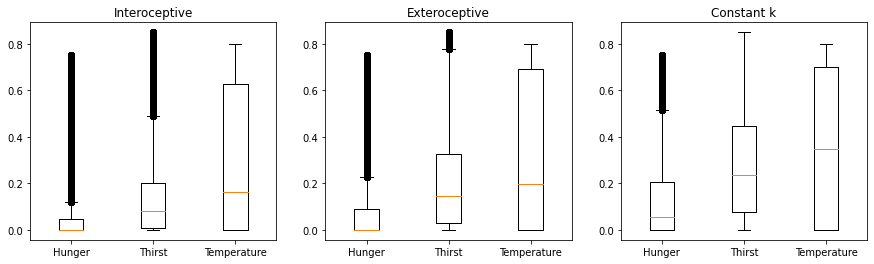

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].set_title('Interoceptive')
axs[0].boxplot([df_allo_0['UHunger'], df_allo_0['UThirst'], df_allo_0['UTemp']], 
            labels=['Hunger','Thirst','Temperature'])

axs[1].set_title('Exteroceptive')
axs[1].boxplot([df_allo_1['UHunger'], df_allo_1['UThirst'], df_allo_1['UTemp']], 
            labels=['Hunger','Thirst','Temperature'])

axs[2].set_title('Constant k')
axs[2].boxplot([df_allo_2['UHunger'], df_allo_2['UThirst'], df_allo_2['UTemp']], 
            labels=['Hunger','Thirst','Temperature'])

In [49]:
df_hunger_U = df_allo['UHunger']
print(round(df_hunger_U.mean(),3))

0.064


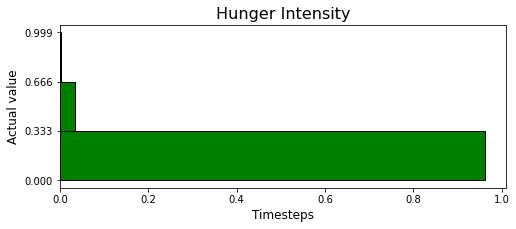

In [59]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_hunger_U)/float(len(df_hunger_U))
plt.hist(df_hunger_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "green", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('Hunger Intensity', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [51]:
top_bin_f=[]
mid_bin_f=[]
bot_bin_f=[]

for i in range(len(df_hunger_U)):
    if df_hunger_U.values[i] <= 1/3:
        bot_bin_f.append(df_hunger_U.values[i])
    if df_hunger_U.values[i] > 1/3 and df_hunger_U.values[i] < 2/3:
        mid_bin_f.append(df_hunger_U.values[i])
    if df_hunger_U.values[i] >= 2/3:
        top_bin_f.append(df_hunger_U.values[i])

if len(bot_bin_f) > 0:
    mean_bot_bin_f = round(sum(bot_bin_f)/len(bot_bin_f),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_f))
    print(len(bot_bin_f))
if len(mid_bin_f) > 0:
    mean_mid_bin_f = round(sum(mid_bin_f)/len(mid_bin_f),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_f))
    print(len(mid_bin_f))
if len(top_bin_f) > 0:
    mean_top_bin_f = round(sum(top_bin_f)/len(top_bin_f),3)
    print("Top_bin mean value = " + str(mean_top_bin_f))
    print(len(top_bin_f))
    
print(len(top_bin_f)/(len(mid_bin_f) + len(bot_bin_f)))

Bot_bin mean value = 0.049
1395099
Mid_bin mean value = 0.431
51249
Top_bin mean value = 0.704
3652
0.002524980156919358


In [60]:
df_thirst_U = df_allo['UThirst']
print(round(df_thirst_U.mean(),3))

0.211


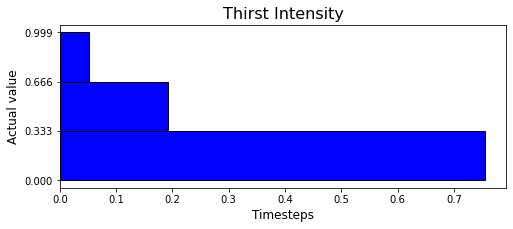

In [63]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_thirst_U)/float(len(df_thirst_U))
plt.hist(df_thirst_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "blue", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('Thirst Intensity', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [64]:
top_bin_w=[]
mid_bin_w=[]
bot_bin_w=[]

for i in range(len(df_thirst_U)):
    if df_thirst_U.values[i] <= 1/3:
        bot_bin_w.append(df_thirst_U.values[i])
    if df_thirst_U.values[i] > 1/3 and df_thirst_U.values[i] < 2/3:
        mid_bin_w.append(df_thirst_U.values[i])
    if df_thirst_U.values[i] >= 2/3:
        top_bin_w.append(df_thirst_U.values[i])

if len(bot_bin_w) > 0:
    mean_bot_bin_w = round(sum(bot_bin_w)/len(bot_bin_w),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_w))
    print(len(bot_bin_w))
if len(mid_bin_w) > 0:
    mean_mid_bin_w = round(sum(mid_bin_w)/len(mid_bin_w),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_w))
    print(len(mid_bin_w))
if len(top_bin_w) > 0:
    mean_top_bin_w = round(sum(top_bin_w)/len(top_bin_w),3)
    print("Top_bin mean value = " + str(mean_top_bin_w))
    print(len(top_bin_w))

print(len(top_bin_w)/(len(mid_bin_w) + len(bot_bin_w)))

Bot_bin mean value = 0.107
1095173
Mid_bin mean value = 0.462
279738
Top_bin mean value = 0.792
75089
0.05461371681512476


In [65]:
df_temp_U = df_allo['UTemp']
print(round(df_temp_U.mean(),3))

0.335


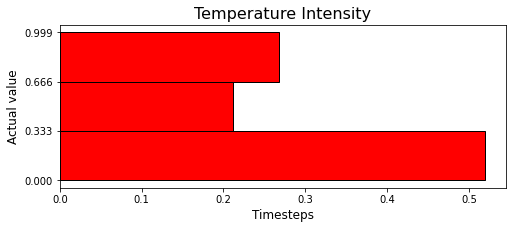

In [90]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_temp_U)/float(len(df_temp_U))
plt.hist(df_temp_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "red", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('Temperature Intensity', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [67]:
top_bin_t=[]
mid_bin_t=[]
bot_bin_t=[]

for i in range(len(df_hunger_U)):
    if df_temp_U.values[i] <= 1/3:
        bot_bin_t.append(df_temp_U.values[i])
    if df_temp_U.values[i] > 1/3 and df_temp_U.values[i] < 2/3:
        mid_bin_t.append(df_temp_U.values[i])
    if df_temp_U.values[i] >= 2/3:
        top_bin_t.append(df_temp_U.values[i])

if len(bot_bin_t) > 0:
    mean_bot_bin_t = round(sum(bot_bin_f)/len(bot_bin_t),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_t))
    print(len(bot_bin_t))
if len(mid_bin_t) > 0:
    mean_mid_bin_t = round(sum(mid_bin_t)/len(mid_bin_t),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_t))
    print(len(mid_bin_t))
if len(top_bin_t) > 0:
    mean_top_bin_t = round(sum(top_bin_t)/len(top_bin_t),3)
    print("Top_bin mean value = " + str(mean_top_bin_t))
    print(len(top_bin_t))
    
print(len(top_bin_t)/(len(mid_bin_t) + len(bot_bin_t)))

Bot_bin mean value = 0.0
753401
Mid_bin mean value = 0.505
307555
Top_bin mean value = 0.775
389044
0.3666919269036605


### Allostasis

#### Allostatic load AL

In [68]:
print("Interoceptive:")
print("Hunger:", round(df_allo_0['ALHunger'].mean(),4))
print("Thirst:", round(df_allo_0['ALThirst'].mean(),4))
print("Temperature:", round(df_allo_0['ALTemp'].mean(),4))

Interoceptive:
Hunger: 0.0521
Thirst: 0.1281
Temperature: 0.0585


In [69]:
print("Exteroceptive:")
print("Hunger:", round(df_allo_1['ALHunger'].mean(),4))
print("Thirst:", round(df_allo_1['ALThirst'].mean(),4))
print("Temperature:", round(df_allo_1['ALTemp'].mean(),4))

Exteroceptive:
Hunger: 0.0423
Thirst: 0.1652
Temperature: 0.0669


In [70]:
print("Constant k:")
print("Hunger:", round(df_allo_2['ALHunger'].mean(),4))
print("Thirst:", round(df_allo_2['ALThirst'].mean(),4))
print("Temperature:", round(df_allo_2['ALTemp'].mean(),4))

Constant k:
Hunger: 0.0875
Thirst: 0.2261
Temperature: 0.0686


In [71]:
df_hunger_AL = df_allo['ALHunger'] 
df_thirst_AL = df_allo['ALThirst'] 
df_temp_AL = df_allo['ALTemp'] 

#### Resource detected n

In [72]:
df_hunger_n = df_allo['NFood']
df_thirst_n = df_allo['NWater']

#### Weighting factor k

In [73]:
print("Interoceptive:")
print("Hunger:", round(df_allo_0['kHunger'].mean(),2), round(df_allo_0['kHunger'].max(),2), round(df_allo_0['kHunger'].std(),4))
print("Thirst:", round(df_allo_0['kThirst'].mean(),2), round(df_allo_0['kThirst'].max(),2), round(df_allo_0['kThirst'].std(),4))
print("Temperature:", round(df_allo_0['kTemp'].mean(),2), round(df_allo_0['kTemp'].max(),2), round(df_allo_0['kTemp'].std(),4))

Interoceptive:
Hunger: 0.81 1.0 0.0511
Thirst: 0.89 1.0 0.0649
Temperature: 0.9 0.97 0.0201


In [74]:
print("Exteroceptive:")
print("Hunger:", round(df_allo_1['kHunger'].mean(),4), round(df_allo_1['kHunger'].max(),4), round(df_allo_1['kHunger'].std(),4))
print("Thirst:", round(df_allo_1['kThirst'].mean(),4), round(df_allo_1['kThirst'].max(),4), round(df_allo_1['kThirst'].std(),4))
print("Temperature:", round(df_allo_1['kTemp'].mean(),4), round(df_allo_1['kTemp'].max(),4), round(df_allo_1['kTemp'].std(),4))

Exteroceptive:
Hunger: 0.8368 1.0 0.0689
Thirst: 0.8845 1.0 0.0734
Temperature: 0.85 0.85 0.0


In [75]:
print("Constant k:")
print("Hunger:", round(df_allo_2['kHunger'].mean(),4), round(df_allo_2['kHunger'].max(),4), round(df_allo_2['kHunger'].std(),4))
print("Thirst:", round(df_allo_2['kThirst'].mean(),4), round(df_allo_2['kThirst'].max(),4), round(df_allo_2['kThirst'].std(),4))
print("Temperature:", round(df_allo_2['kTemp'].mean(),4), round(df_allo_2['kTemp'].max(),4), round(df_allo_2['kTemp'].std(),4))

Constant k:
Hunger: 0.78 0.78 0.0
Thirst: 0.8 0.8 0.0
Temperature: 0.85 0.85 0.0


In [76]:
df_hunger_K = df_allo['kHunger'] 
df_thirst_K = df_allo['kThirst'] 
df_temp_K = df_allo['kTemp'] 

#### Force f = 1 + ∣aV - dV∣ * k

In [77]:
print("Interoceptive:")
print("Hunger:", round((df_allo_0['DHunger']+1).mean(),4), round((df_allo_0['DHunger']+1).max(),4), round((df_allo_0['DHunger']+1).std(),4))
print("Thirst:", round((df_allo_0['DThirst']+1).mean(),4), round((df_allo_0['DThirst']+1).max(),4), round((df_allo_0['DThirst']+1).std(),4))
print("Temperature:", round((df_allo_0['DTemp']+1).mean(),4), round((df_allo_0['DTemp']+1).max(),4), round((df_allo_0['DTemp']+1).std(),4))

Interoceptive:
Hunger: 1.049 1.75 0.1208
Thirst: 1.1346 1.85 0.1781
Temperature: 1.274 1.776 0.2841


In [78]:
print("Exteroceptive:")
print("Hunger:", round((df_allo_1['DHunger']+1).mean(),4), round((df_allo_1['DHunger']+1).max(),4), round((df_allo_1['DHunger']+1).std(),4))
print("Thirst:", round((df_allo_1['DThirst']+1).mean(),4), round((df_allo_1['DThirst']+1).max(),4), round((df_allo_1['DThirst']+1).std(),4))
print("Temperature:", round((df_allo_1['DTemp']+1).mean(),4), round((df_allo_1['DTemp']+1).max(),4), round((df_allo_1['DTemp']+1).std(),4))

Exteroceptive:
Hunger: 1.0517 1.6073 0.0897
Thirst: 1.1857 1.85 0.1931
Temperature: 1.2849 1.68 0.2806


In [79]:
print("Constant k:")
print("Hunger:", round((df_allo_2['DHunger']+1).mean(),4), round((df_allo_2['DHunger']+1).max(),4), round((df_allo_2['DHunger']+1).std(),4))
print("Thirst:", round((df_allo_2['DThirst']+1).mean(),4), round((df_allo_2['DThirst']+1).max(),4), round((df_allo_2['DThirst']+1).std(),4))
print("Temperature:", round((df_allo_2['DTemp']+1).mean(),4), round((df_allo_2['DTemp']+1).max(),4), round((df_allo_2['DTemp']+1).std(),4))

Constant k:
Hunger: 1.0981 1.585 0.1258
Thirst: 1.231 1.68 0.1974
Temperature: 1.3095 1.68 0.2776


In [88]:
df_hunger_D = df_allo['DHunger'] + 1
df_thirst_D = df_allo['DThirst'] + 1
df_temp_D = df_allo['DTemp'] + 1

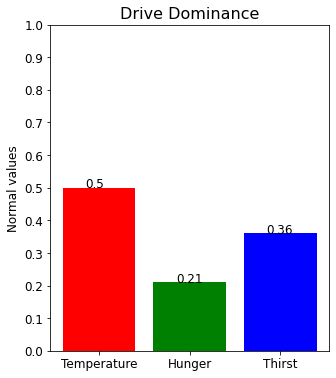

In [89]:
temp_count = 0
food_count = 0
water_count = 0

for i in range(len(df_temp_D)):
    if df_temp_D.values[i] > df_thirst_D.values[i] and df_temp_D.values[i] > df_hunger_D.values[i] and df_temp_D.values[i] > 0.3:
        temp_count += 1
    if df_hunger_D.values[i] > df_temp_D.values[i] and df_hunger_D.values[i] > df_temp_D.values[i]:
        food_count += 1
    if df_thirst_D.values[i] > df_temp_D.values[i] and df_thirst_D.values[i] > df_hunger_D.values[i]:
        water_count += 1
        
norm_t = temp_count/len(df_temp_D)
norm_f = food_count/len(df_hunger_D)
norm_w = water_count/len(df_thirst_D)

objects = ('Temperature', 'Hunger', 'Thirst')
y_pos = np.arange(len(objects))
values = [round(norm_t , 2), round(norm_f, 2), round(norm_w, 2)]

plt.figure(figsize=(5, 6))
plt.bar(y_pos, values, align='center', color=['red', 'green', 'blue'])
plt.xticks(y_pos, objects, fontsize=12)
plt.ylabel('Normal values', fontsize=12)
plt.yticks(np.arange(0, 1.1, step=0.1), fontsize=12)
plt.title('Drive Dominance', fontsize=16)

for index, value in enumerate(values):
    plt.text(index-0.15, value, str(value), fontsize=12)
plt.show()

In [82]:
hunger_corr = pd.concat([df_hunger_n, df_hunger_U, df_hunger_AL, df_hunger_K, df_hunger_D], axis=1).corr()
print(hunger_corr)

             NFood   UHunger  ALHunger   kHunger   DHunger
NFood     1.000000  0.156128  0.325165 -0.618183  0.140995
UHunger   0.156128  1.000000  0.532797 -0.219149  0.999058
ALHunger  0.325165  0.532797  1.000000 -0.331617  0.534227
kHunger  -0.618183 -0.219149 -0.331617  1.000000 -0.203878
DHunger   0.140995  0.999058  0.534227 -0.203878  1.000000


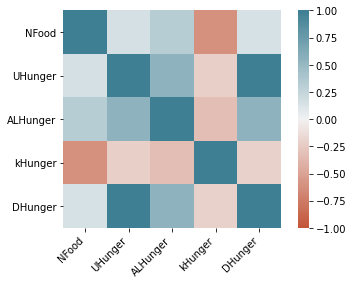

In [83]:
ax = sns.heatmap(
    hunger_corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=500),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [84]:
thirst_corr = pd.concat([df_thirst_n, df_thirst_U, df_thirst_AL, df_thirst_K, df_thirst_D], axis=1).corr()
print(thirst_corr)

            NWater   UThirst  ALThirst   kThirst   DThirst
NWater    1.000000  0.056082  0.159694 -0.661031 -0.000137
UThirst   0.056082  1.000000  0.508869 -0.034128  0.993919
ALThirst  0.159694  0.508869  1.000000 -0.221590  0.520871
kThirst  -0.661031 -0.034128 -0.221590  1.000000  0.041031
DThirst  -0.000137  0.993919  0.520871  0.041031  1.000000


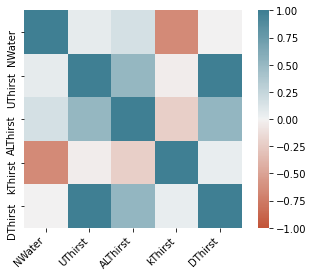

In [85]:
ax = sns.heatmap(
    thirst_corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=500),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [91]:
r, p = sci.pearsonr(df_hunger_K, df_hunger_n)
print(r,p)

-0.6181825668467404 0.0


In [92]:
r, p = sci.pearsonr(df_thirst_K, df_thirst_n)
print(r,p)

-0.6610313650703767 0.0
